# Temporal Analysis of Gender Representation

Analysis of how gender representation varies by time of day and day of week in Mumbai and Navi Mumbai street images.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading & Temporal Coverage

In [2]:
df = pd.read_csv('../../data/mumbai_annotations_with_exif.csv')

count_cols = ['men_count', 'women_count', 'men_twowheeler', 'women_twowheeler']
for col in count_cols:
    df[col] = df[col].fillna(0)

df['total_women'] = df['women_count'] + df['women_twowheeler']
df['total_men'] = df['men_count'] + df['men_twowheeler']
df['total_people'] = df['total_women'] + df['total_men']
df['prop_women'] = df['total_women'] / df['total_people'].replace(0, np.nan)

print(f"Total annotations: {len(df)}")
print(f"Mumbai: {len(df[df['region'] == 'mumbai'])}")
print(f"Navi Mumbai: {len(df[df['region'] == 'navi_mumbai'])}")

Total annotations: 4000
Mumbai: 2744
Navi Mumbai: 1256


In [3]:
print("Temporal Coverage:")
print(f"  Hours: {int(df['frame_hour'].min())} - {int(df['frame_hour'].max())} ({int(df['frame_hour'].min())} AM - {int(df['frame_hour'].max())-12 if df['frame_hour'].max() > 12 else int(df['frame_hour'].max())} {'PM' if df['frame_hour'].max() > 12 else 'AM'})")
print(f"  Days: All 7 days of week covered")

print(f"\nDate range:")
df['frame_datetime'] = pd.to_datetime(df['frame_datetime'])
print(f"  {df['frame_datetime'].min().date()} to {df['frame_datetime'].max().date()}")

Temporal Coverage:
  Hours: 7 - 19 (7 AM - 7 PM)
  Days: All 7 days of week covered

Date range:
  2021-03-09 to 2025-05-15


### Data Collection Caveats

**Important limitations to consider:**

1. **No evening/night data**: All observations are from morning to evening (approximately 6:30 AM - 7:30 PM IST).

2. **Day-of-week imbalance**: Thursday is heavily overrepresented (40% of data), while Wednesday is underrepresented (1%). This limits day-of-week analysis reliability.

**Note on timestamps**: GoPro records in UTC. All times have been converted to IST (UTC+5:30) for analysis.

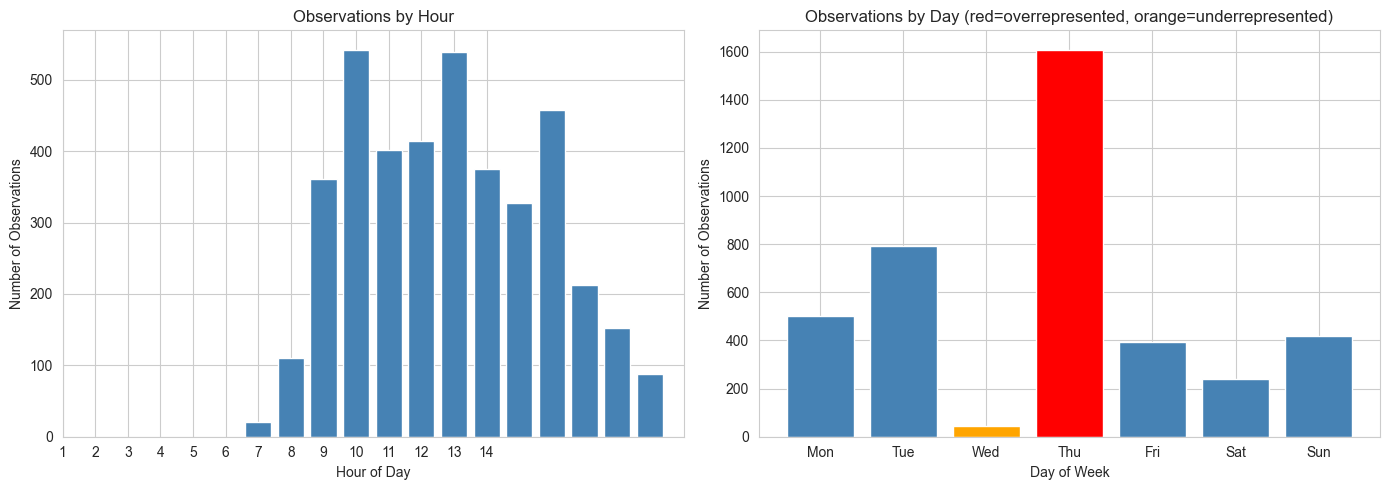


Sample size by day of week:
  Mon: 503 (12.6%)
  Tue: 792 (19.8%)
  Wed: 45 (1.1%) ** UNDERREPRESENTED
  Thu: 1608 (40.2%) ** OVERREPRESENTED
  Fri: 395 (9.9%)
  Sat: 238 (5.9%)
  Sun: 419 (10.5%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_counts = df['frame_hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='steelblue')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Observations')
axes[0].set_title('Observations by Hour')
axes[0].set_xticks(range(1, 15))

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df['frame_dayofweek'].value_counts().sort_index()
colors = ['red' if v/len(df) > 0.3 else 'orange' if v/len(df) < 0.05 else 'steelblue' for v in day_counts.values]
axes[1].bar([day_names[i] for i in day_counts.index], day_counts.values, color=colors)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Observations')
axes[1].set_title('Observations by Day (red=overrepresented, orange=underrepresented)')

plt.tight_layout()
plt.show()

print("\nSample size by day of week:")
for i, name in enumerate(day_names):
    n = day_counts.get(i, 0)
    pct = n / len(df) * 100
    flag = " ** OVERREPRESENTED" if pct > 30 else " ** UNDERREPRESENTED" if pct < 5 else ""
    print(f"  {name}: {n} ({pct:.1f}%){flag}")

## 2. Time of Day Analysis

In [5]:
df_with_people = df[df['total_people'] > 0].copy()

hourly_stats = []
for hour in sorted(df_with_people['frame_hour'].dropna().unique()):
    hour_data = df_with_people[df_with_people['frame_hour'] == hour]
    pw = hour_data['prop_women'].dropna()
    
    weighted_prop = hour_data['total_women'].sum() / hour_data['total_people'].sum()
    
    ci_low, ci_high = np.nan, np.nan
    if len(pw) >= 2:
        ci = stats.t.interval(0.95, len(pw)-1, loc=pw.mean(), scale=stats.sem(pw))
        ci_low, ci_high = ci
    
    hourly_stats.append({
        'hour': int(hour),
        'n': len(hour_data),
        'total_people': hour_data['total_people'].sum(),
        'mean_busyness': hour_data['total_people'].mean(),
        'prop_women_unweighted': pw.mean(),
        'prop_women_weighted': weighted_prop,
        'ci_low': ci_low,
        'ci_high': ci_high
    })

hourly_df = pd.DataFrame(hourly_stats)
print("Proportion Women by Hour of Day:")
print(hourly_df.to_string(index=False))

Proportion Women by Hour of Day:
 hour   n  total_people  mean_busyness  prop_women_unweighted  prop_women_weighted   ci_low  ci_high
    7  16          78.0       4.875000               0.220391             0.256410 0.065936 0.374847
    8  97         683.0       7.041237               0.124701             0.136164 0.089561 0.159841
    9 337        2112.0       6.267062               0.117022             0.128314 0.097807 0.136237
   10 469        2642.0       5.633262               0.157268             0.171840 0.138254 0.176282
   11 353        2377.0       6.733711               0.170441             0.182583 0.148984 0.191898
   12 349        1905.0       5.458453               0.175847             0.215223 0.150094 0.201600
   13 482        3282.0       6.809129               0.125689             0.139244 0.108790 0.142588
   14 333        2266.0       6.804805               0.113706             0.136364 0.094464 0.132947
   15 277        1512.0       5.458484               0.145

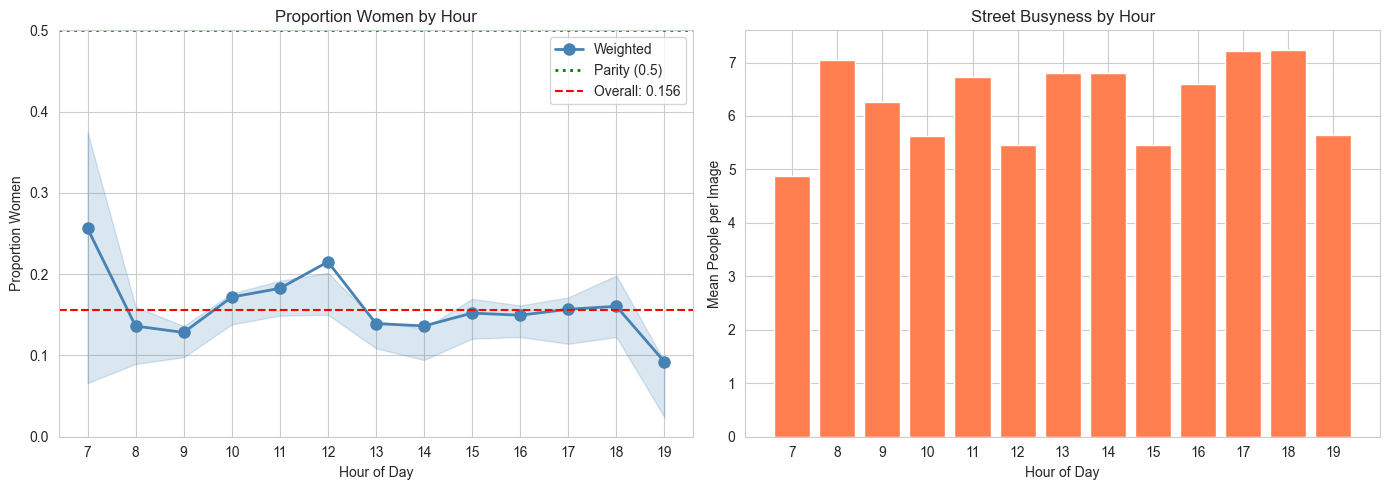

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(hourly_df['hour'], hourly_df['prop_women_weighted'], 'o-', color='steelblue', linewidth=2, markersize=8, label='Weighted')
ax1.fill_between(hourly_df['hour'], hourly_df['ci_low'], hourly_df['ci_high'], alpha=0.2, color='steelblue')
ax1.axhline(0.5, color='green', linestyle=':', linewidth=2, label='Parity (0.5)')
overall_prop = df_with_people['total_women'].sum() / df_with_people['total_people'].sum()
ax1.axhline(overall_prop, color='red', linestyle='--', label=f'Overall: {overall_prop:.3f}')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Proportion Women')
ax1.set_title('Proportion Women by Hour')
ax1.legend()
ax1.set_xticks(hourly_df['hour'])
ax1.set_ylim(0, 0.5)

ax2 = axes[1]
ax2.bar(hourly_df['hour'], hourly_df['mean_busyness'], color='coral')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Mean People per Image')
ax2.set_title('Street Busyness by Hour')
ax2.set_xticks(hourly_df['hour'])

plt.tight_layout()
plt.show()

In [7]:
hour_groups = [df_with_people[df_with_people['frame_hour'] == h]['prop_women'].dropna().values 
               for h in sorted(df_with_people['frame_hour'].dropna().unique())]
hour_groups = [g for g in hour_groups if len(g) >= 5]

stat, p_value = stats.kruskal(*hour_groups)
print(f"Kruskal-Wallis test (prop women ~ hour):")
print(f"  H-statistic: {stat:.3f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Significant at p<0.05: {'Yes' if p_value < 0.05 else 'No'}")

Kruskal-Wallis test (prop women ~ hour):
  H-statistic: 59.332
  p-value: 0.0000
  Significant at p<0.05: Yes


### Time Period Analysis (Binned)

Time periods in IST (Indian Standard Time) - equal 4-hour windows:

In [8]:
def assign_time_period(hour):
    if pd.isna(hour):
        return np.nan
    if hour < 11:
        return 'Morning (7-11 IST)'
    elif hour < 15:
        return 'Midday (11-15 IST)'
    else:
        return 'Evening (15-19 IST)'

df_with_people['time_period'] = df_with_people['frame_hour'].apply(assign_time_period)

period_stats = []
for period in ['Morning (7-11 IST)', 'Midday (11-15 IST)', 'Evening (15-19 IST)']:
    period_data = df_with_people[df_with_people['time_period'] == period]
    if len(period_data) > 0:
        weighted_prop = period_data['total_women'].sum() / period_data['total_people'].sum()
        period_stats.append({
            'period': period,
            'n': len(period_data),
            'prop_women': weighted_prop,
            'mean_busyness': period_data['total_people'].mean()
        })

period_df = pd.DataFrame(period_stats)
print("Proportion Women by Time Period (IST):")
print(period_df.to_string(index=False))

Proportion Women by Time Period (IST):
             period    n  prop_women  mean_busyness
 Morning (7-11 IST)  919    0.151949       6.001088
 Midday (11-15 IST) 1517    0.163784       6.479895
Evening (15-19 IST) 1086    0.149448       6.426335


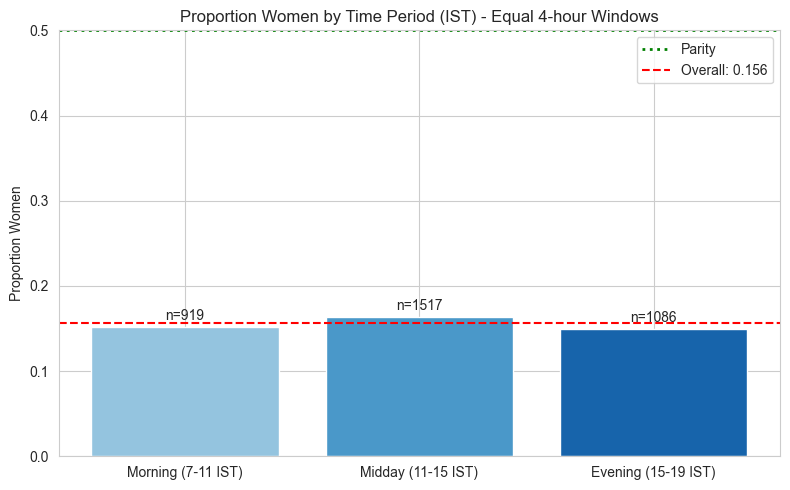

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(period_df)))
bars = ax.bar(period_df['period'], period_df['prop_women'], color=colors)

for bar, n in zip(bars, period_df['n']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'n={n}', 
            ha='center', va='bottom', fontsize=10)

ax.axhline(0.5, color='green', linestyle=':', linewidth=2, label='Parity')
ax.axhline(overall_prop, color='red', linestyle='--', label=f'Overall: {overall_prop:.3f}')
ax.set_ylabel('Proportion Women')
ax.set_title('Proportion Women by Time Period (IST) - Equal 4-hour Windows')
ax.legend()
ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.show()

## 3. Day of Week Analysis

**Caveat**: Sample sizes vary dramatically by day. Thursday has 40% of all observations while Wednesday has only 1%. Interpret day-of-week patterns with caution.

In [10]:
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_stats = []
for day in range(7):
    day_data = df_with_people[df_with_people['frame_dayofweek'] == day]
    if len(day_data) > 0:
        pw = day_data['prop_women'].dropna()
        weighted_prop = day_data['total_women'].sum() / day_data['total_people'].sum()
        
        ci_low, ci_high = np.nan, np.nan
        if len(pw) >= 2:
            ci = stats.t.interval(0.95, len(pw)-1, loc=pw.mean(), scale=stats.sem(pw))
            ci_low, ci_high = ci
        
        daily_stats.append({
            'day': day_names[day],
            'day_num': day,
            'n': len(day_data),
            'pct_of_data': len(day_data) / len(df_with_people) * 100,
            'prop_women_unweighted': pw.mean(),
            'prop_women_weighted': weighted_prop,
            'ci_low': ci_low,
            'ci_high': ci_high,
            'mean_busyness': day_data['total_people'].mean()
        })

daily_df = pd.DataFrame(daily_stats)
print("Proportion Women by Day of Week:")
print(daily_df[['day', 'n', 'pct_of_data', 'prop_women_weighted', 'mean_busyness']].to_string(index=False))

Proportion Women by Day of Week:
      day    n  pct_of_data  prop_women_weighted  mean_busyness
   Monday  388    11.016468             0.153475       5.340206
  Tuesday  680    19.307212             0.154441       5.894118
Wednesday   39     1.107325             0.180000       3.846154
 Thursday 1465    41.595684             0.162196       6.464164
   Friday  363    10.306644             0.151596       7.250689
 Saturday  224     6.360023             0.145172       6.888393
   Sunday  363    10.306644             0.150265       6.746556


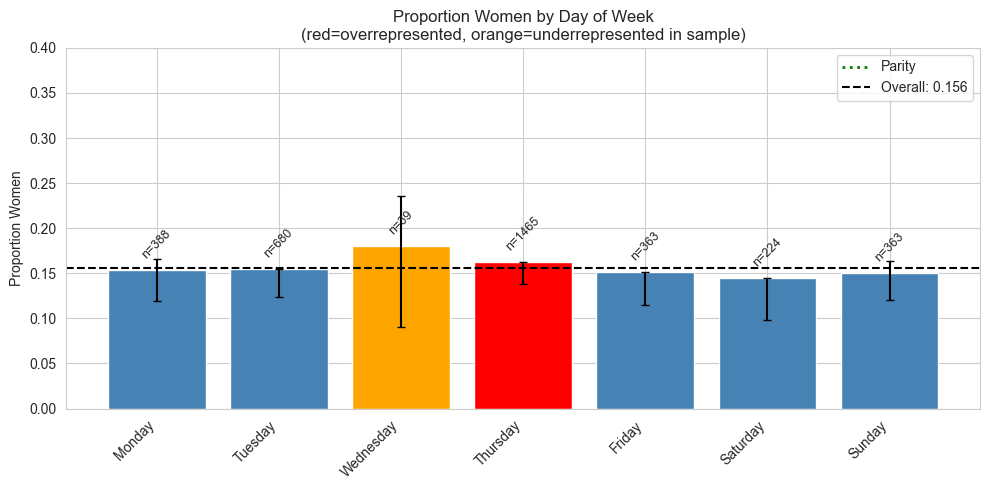

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['red' if row['pct_of_data'] > 30 else 'orange' if row['pct_of_data'] < 5 else 'steelblue' 
          for _, row in daily_df.iterrows()]

yerr_low = np.maximum(0, daily_df['prop_women_weighted'] - daily_df['ci_low'])
yerr_high = np.maximum(0, daily_df['ci_high'] - daily_df['prop_women_weighted'])

bars = ax.bar(daily_df['day'], daily_df['prop_women_weighted'], color=colors, 
              yerr=[yerr_low, yerr_high], capsize=3)

for bar, n in zip(bars, daily_df['n']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'n={n}', 
            ha='center', va='bottom', fontsize=9, rotation=45)

ax.axhline(0.5, color='green', linestyle=':', linewidth=2, label='Parity')
ax.axhline(overall_prop, color='black', linestyle='--', label=f'Overall: {overall_prop:.3f}')
ax.set_ylabel('Proportion Women')
ax.set_title('Proportion Women by Day of Week\n(red=overrepresented, orange=underrepresented in sample)')
ax.legend()
ax.set_ylim(0, 0.4)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Weekday vs Weekend

In [12]:
df_with_people['is_weekend'] = df_with_people['frame_dayofweek'].isin([5, 6])

weekday_data = df_with_people[~df_with_people['is_weekend']]
weekend_data = df_with_people[df_with_people['is_weekend']]

weekday_prop = weekday_data['total_women'].sum() / weekday_data['total_people'].sum()
weekend_prop = weekend_data['total_women'].sum() / weekend_data['total_people'].sum()

print("Weekday vs Weekend:")
print(f"  Weekday (Mon-Fri): n={len(weekday_data)}, prop women={weekday_prop:.3f}")
print(f"  Weekend (Sat-Sun): n={len(weekend_data)}, prop women={weekend_prop:.3f}")

weekday_pw = weekday_data['prop_women'].dropna()
weekend_pw = weekend_data['prop_women'].dropna()

u_stat, p_val = stats.mannwhitneyu(weekday_pw, weekend_pw, alternative='two-sided')
print(f"\nMann-Whitney U test:")
print(f"  U-statistic: {u_stat:.1f}")
print(f"  p-value: {p_val:.4f}")
print(f"  Significant at p<0.05: {'Yes' if p_val < 0.05 else 'No'}")

Weekday vs Weekend:
  Weekday (Mon-Fri): n=2935, prop women=0.158
  Weekend (Sat-Sun): n=587, prop women=0.148

Mann-Whitney U test:
  U-statistic: 879976.5
  p-value: 0.3741
  Significant at p<0.05: No


## 4. Road Type x Time Interactions

Does the relationship between road type and proportion women vary by time of day?

In [13]:
TARGET_ROAD_TYPES = ['primary', 'secondary', 'tertiary', 'residential']
df_roads = df_with_people[df_with_people['road_type'].isin(TARGET_ROAD_TYPES)].copy()
df_roads['time_period'] = df_roads['frame_hour'].apply(assign_time_period)

print(f"Observations with road type and time data: {len(df_roads)}")

Observations with road type and time data: 2914


In [14]:
interaction_stats = []
for road_type in TARGET_ROAD_TYPES:
    for period in ['Morning (7-11 IST)', 'Midday (11-15 IST)', 'Evening (15-19 IST)']:
        subset = df_roads[(df_roads['road_type'] == road_type) & (df_roads['time_period'] == period)]
        if len(subset) >= 5:
            weighted_prop = subset['total_women'].sum() / subset['total_people'].sum()
            interaction_stats.append({
                'road_type': road_type,
                'time_period': period,
                'n': len(subset),
                'prop_women': weighted_prop
            })

interaction_df = pd.DataFrame(interaction_stats)
print("Proportion Women by Road Type and Time Period (IST):")
print(interaction_df.to_string(index=False))

Proportion Women by Road Type and Time Period (IST):
  road_type         time_period   n  prop_women
    primary  Morning (7-11 IST)  83    0.143763
    primary  Midday (11-15 IST) 152    0.150000
    primary Evening (15-19 IST)  97    0.158182
  secondary  Morning (7-11 IST) 132    0.101572
  secondary  Midday (11-15 IST) 254    0.131875
  secondary Evening (15-19 IST) 217    0.125610
   tertiary  Morning (7-11 IST)  93    0.169165
   tertiary  Midday (11-15 IST) 206    0.155867
   tertiary Evening (15-19 IST) 206    0.157669
residential  Morning (7-11 IST) 384    0.162037
residential  Midday (11-15 IST) 717    0.169868
residential Evening (15-19 IST) 373    0.158788


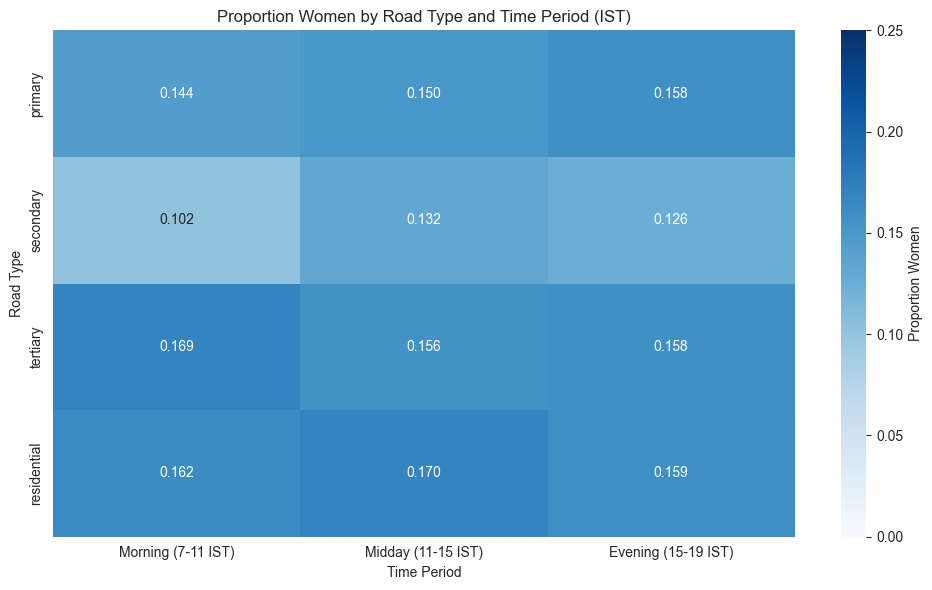

In [15]:
pivot_df = interaction_df.pivot(index='road_type', columns='time_period', values='prop_women')
pivot_df = pivot_df[['Morning (7-11 IST)', 'Midday (11-15 IST)', 'Evening (15-19 IST)']]
pivot_df = pivot_df.reindex(TARGET_ROAD_TYPES)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, fmt='.3f', cmap='Blues', ax=ax, 
            vmin=0, vmax=0.25, cbar_kws={'label': 'Proportion Women'})
ax.set_title('Proportion Women by Road Type and Time Period (IST)')
ax.set_xlabel('Time Period')
ax.set_ylabel('Road Type')
plt.tight_layout()
plt.show()

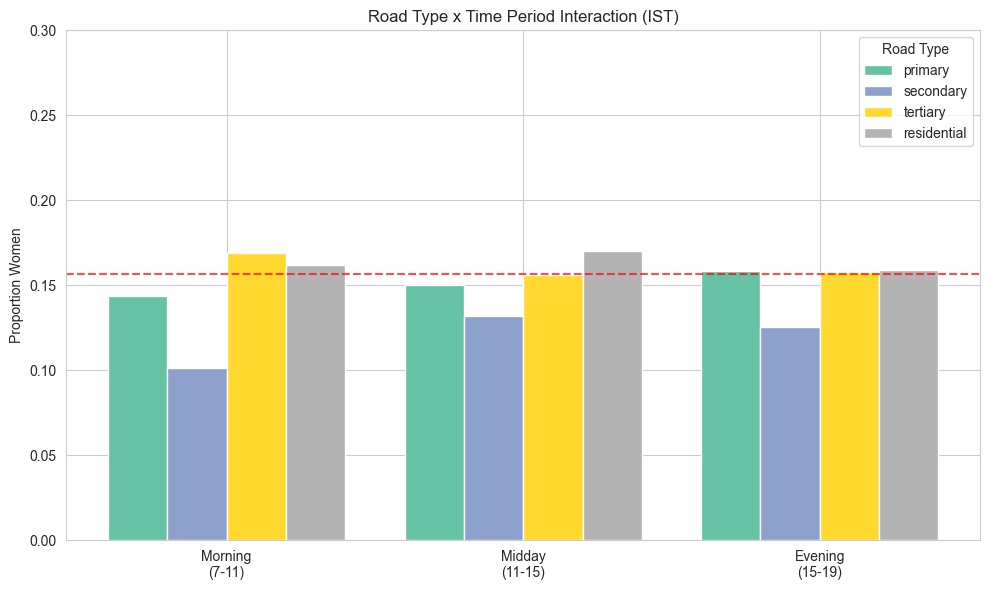

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

periods = ['Morning (7-11 IST)', 'Midday (11-15 IST)', 'Evening (15-19 IST)']
x = np.arange(len(periods))
width = 0.2
colors = plt.cm.Set2(np.linspace(0, 1, len(TARGET_ROAD_TYPES)))

for i, road_type in enumerate(TARGET_ROAD_TYPES):
    road_data = interaction_df[interaction_df['road_type'] == road_type]
    values = [road_data[road_data['time_period'] == p]['prop_women'].values[0] 
              if len(road_data[road_data['time_period'] == p]) > 0 else 0 for p in periods]
    ax.bar(x + i*width, values, width, label=road_type, color=colors[i])

ax.set_ylabel('Proportion Women')
ax.set_title('Road Type x Time Period Interaction (IST)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Morning\n(7-11)', 'Midday\n(11-15)', 'Evening\n(15-19)'])
ax.legend(title='Road Type')
ax.set_ylim(0, 0.3)
ax.axhline(overall_prop, color='red', linestyle='--', alpha=0.7, label='Overall')

plt.tight_layout()
plt.show()

## 5. Regional Comparison

In [17]:
regional_hourly = []
for region in ['mumbai', 'navi_mumbai']:
    region_data = df_with_people[df_with_people['region'] == region]
    for hour in sorted(region_data['frame_hour'].dropna().unique()):
        hour_data = region_data[region_data['frame_hour'] == hour]
        if len(hour_data) >= 5:
            weighted_prop = hour_data['total_women'].sum() / hour_data['total_people'].sum()
            regional_hourly.append({
                'region': region,
                'hour': int(hour),
                'n': len(hour_data),
                'prop_women': weighted_prop
            })

regional_df = pd.DataFrame(regional_hourly)

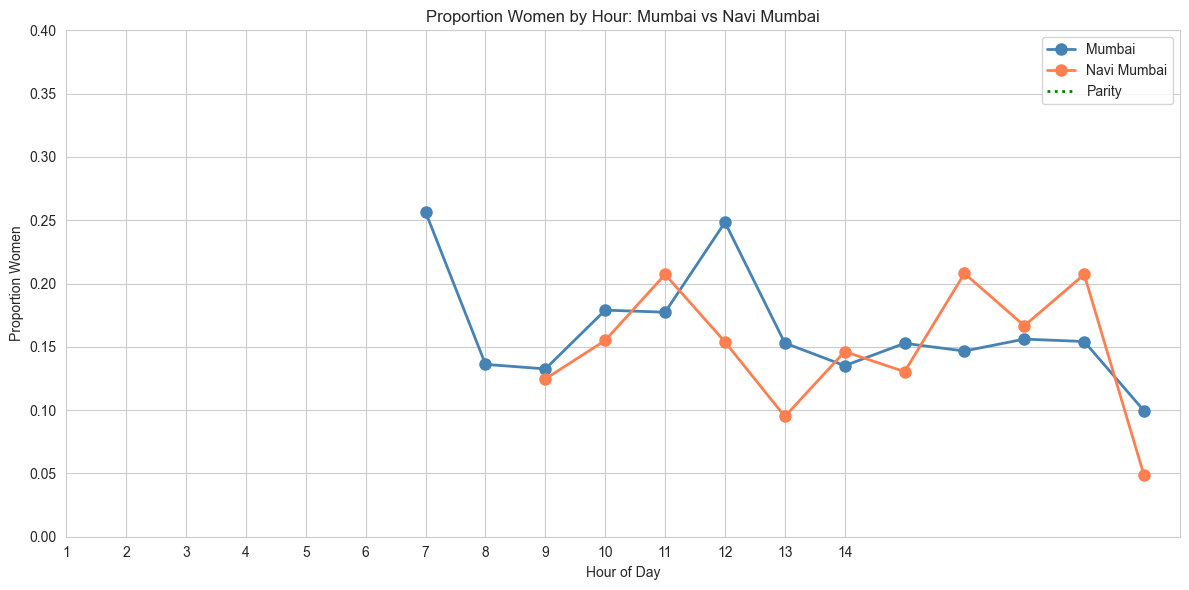

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

for region, color in [('mumbai', 'steelblue'), ('navi_mumbai', 'coral')]:
    region_data = regional_df[regional_df['region'] == region]
    ax.plot(region_data['hour'], region_data['prop_women'], 'o-', color=color, 
            linewidth=2, markersize=8, label=region.replace('_', ' ').title())

ax.axhline(0.5, color='green', linestyle=':', linewidth=2, label='Parity')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Proportion Women')
ax.set_title('Proportion Women by Hour: Mumbai vs Navi Mumbai')
ax.legend()
ax.set_xticks(range(1, 15))
ax.set_ylim(0, 0.4)

plt.tight_layout()
plt.show()

## 6. Gender by Points of Interest (POI)

Analysis of gender representation near bus stations, railway stations, and street vendors.

In [19]:
poi_fields = ['bus_station', 'railway_station', 'street_vendor']

print("POI Sample Sizes (both cities):")
for poi in poi_fields:
    yes_count = (df[poi] == 'Yes').sum()
    no_count = (df[poi] == 'No').sum()
    print(f"  {poi}: Yes={yes_count}, No={no_count}")

POI Sample Sizes (both cities):
  bus_station: Yes=146, No=3854
  railway_station: Yes=8, No=3992
  street_vendor: Yes=239, No=3760


In [20]:
poi_stats = []
for region in ['mumbai', 'navi_mumbai', 'all']:
    if region == 'all':
        region_data = df_with_people
    else:
        region_data = df_with_people[df_with_people['region'] == region]
    
    for poi in poi_fields:
        for val in ['Yes', 'No']:
            subset = region_data[region_data[poi] == val]
            if len(subset) >= 5 and subset['total_people'].sum() > 0:
                weighted_prop = subset['total_women'].sum() / subset['total_people'].sum()
                poi_stats.append({
                    'region': region,
                    'poi': poi,
                    'value': val,
                    'n': len(subset),
                    'prop_women': weighted_prop
                })

poi_df = pd.DataFrame(poi_stats)
print("Proportion Women by POI and Region:")
print(poi_df.to_string(index=False))

Proportion Women by POI and Region:
     region             poi value    n  prop_women
     mumbai     bus_station   Yes   90    0.166881
     mumbai     bus_station    No 2468    0.159583
     mumbai railway_station   Yes    7    0.141026
     mumbai railway_station    No 2551    0.159984
     mumbai   street_vendor   Yes  186    0.219159
     mumbai   street_vendor    No 2371    0.151855
navi_mumbai     bus_station   Yes   47    0.171521
navi_mumbai     bus_station    No  917    0.140225
navi_mumbai railway_station    No  964    0.142380
navi_mumbai   street_vendor   Yes   52    0.153318
navi_mumbai   street_vendor    No  912    0.141200
        all     bus_station   Yes  137    0.168199
        all     bus_station    No 3385    0.155773
        all railway_station   Yes    7    0.141026
        all railway_station    No 3515    0.156433
        all   street_vendor   Yes  238    0.207994
        all   street_vendor    No 3283    0.149668


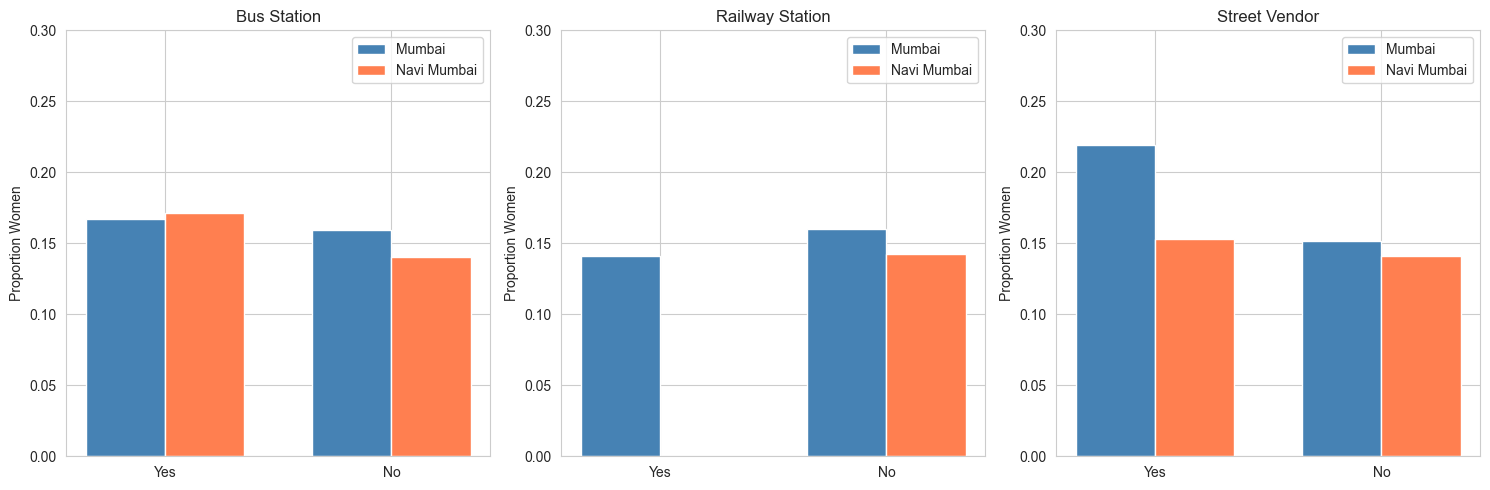

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, poi in zip(axes, poi_fields):
    poi_data = poi_df[(poi_df['poi'] == poi) & (poi_df['region'] != 'all')]
    
    x = np.arange(2)
    width = 0.35
    
    mumbai_yes = poi_data[(poi_data['region'] == 'mumbai') & (poi_data['value'] == 'Yes')]['prop_women'].values
    mumbai_no = poi_data[(poi_data['region'] == 'mumbai') & (poi_data['value'] == 'No')]['prop_women'].values
    navi_yes = poi_data[(poi_data['region'] == 'navi_mumbai') & (poi_data['value'] == 'Yes')]['prop_women'].values
    navi_no = poi_data[(poi_data['region'] == 'navi_mumbai') & (poi_data['value'] == 'No')]['prop_women'].values
    
    mumbai_vals = [mumbai_yes[0] if len(mumbai_yes) > 0 else 0, mumbai_no[0] if len(mumbai_no) > 0 else 0]
    navi_vals = [navi_yes[0] if len(navi_yes) > 0 else 0, navi_no[0] if len(navi_no) > 0 else 0]
    
    ax.bar(x - width/2, mumbai_vals, width, label='Mumbai', color='steelblue')
    ax.bar(x + width/2, navi_vals, width, label='Navi Mumbai', color='coral')
    
    ax.set_ylabel('Proportion Women')
    ax.set_title(poi.replace('_', ' ').title())
    ax.set_xticks(x)
    ax.set_xticklabels(['Yes', 'No'])
    ax.legend()
    ax.set_ylim(0, 0.3)

plt.tight_layout()
plt.show()

In [22]:
print("Statistical Tests - POI Effects:")
for poi in poi_fields:
    yes_data = df_with_people[(df_with_people[poi] == 'Yes')]['prop_women'].dropna()
    no_data = df_with_people[(df_with_people[poi] == 'No')]['prop_women'].dropna()
    
    if len(yes_data) >= 5 and len(no_data) >= 5:
        u_stat, p_val = stats.mannwhitneyu(yes_data, no_data, alternative='two-sided')
        yes_prop = df_with_people[df_with_people[poi] == 'Yes']['total_women'].sum() / df_with_people[df_with_people[poi] == 'Yes']['total_people'].sum()
        no_prop = df_with_people[df_with_people[poi] == 'No']['total_women'].sum() / df_with_people[df_with_people[poi] == 'No']['total_people'].sum()
        print(f"\n{poi}:")
        print(f"  Yes: {yes_prop:.3f} (n={len(yes_data)}), No: {no_prop:.3f} (n={len(no_data)})")
        print(f"  Mann-Whitney U: p={p_val:.4f}")
        print(f"  Significant at p<0.05: {'Yes' if p_val < 0.05 else 'No'}")
    else:
        print(f"\n{poi}: Insufficient data for statistical test")

Statistical Tests - POI Effects:

bus_station:
  Yes: 0.168 (n=137), No: 0.156 (n=3385)
  Mann-Whitney U: p=0.0409
  Significant at p<0.05: Yes

railway_station:
  Yes: 0.141 (n=7), No: 0.156 (n=3515)
  Mann-Whitney U: p=0.7229
  Significant at p<0.05: No

street_vendor:
  Yes: 0.208 (n=238), No: 0.150 (n=3283)
  Mann-Whitney U: p=0.0000
  Significant at p<0.05: Yes


## 7. City-Specific Temporal Analysis

Comparing temporal patterns between Mumbai and Navi Mumbai.

In [23]:
print("Temporal Coverage by City:")
for region in ['mumbai', 'navi_mumbai']:
    region_data = df[df['region'] == region]
    print(f"\n{region.replace('_', ' ').title()}:")
    print(f"  Total observations: {len(region_data)}")
    print(f"  Hours: {int(region_data['frame_hour'].min())} - {int(region_data['frame_hour'].max())}")
    print(f"  Day distribution:")
    day_counts = region_data['frame_dayofweek'].value_counts().sort_index()
    for i, name in enumerate(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']):
        n = day_counts.get(i, 0)
        pct = n / len(region_data) * 100 if len(region_data) > 0 else 0
        print(f"    {name}: {n} ({pct:.1f}%)")

Temporal Coverage by City:

Mumbai:
  Total observations: 2744
  Hours: 7 - 19
  Day distribution:
    Mon: 218 (7.9%)
    Tue: 303 (11.0%)
    Wed: 0 (0.0%)
    Thu: 1346 (49.1%)
    Fri: 395 (14.4%)
    Sat: 238 (8.7%)
    Sun: 244 (8.9%)

Navi Mumbai:
  Total observations: 1256
  Hours: 9 - 19
  Day distribution:
    Mon: 285 (22.7%)
    Tue: 489 (38.9%)
    Wed: 45 (3.6%)
    Thu: 262 (20.9%)
    Fri: 0 (0.0%)
    Sat: 0 (0.0%)
    Sun: 175 (13.9%)


In [24]:
print("Proportion Women by Time Period and City (IST):")
print("="*60)

for region in ['mumbai', 'navi_mumbai']:
    region_data = df_with_people[df_with_people['region'] == region].copy()
    region_data['time_period'] = region_data['frame_hour'].apply(assign_time_period)
    
    print(f"\n{region.replace('_', ' ').title()}:")
    for period in ['Morning (7-11 IST)', 'Midday (11-15 IST)', 'Evening (15-19 IST)']:
        period_data = region_data[region_data['time_period'] == period]
        if len(period_data) > 0 and period_data['total_people'].sum() > 0:
            weighted_prop = period_data['total_women'].sum() / period_data['total_people'].sum()
            print(f"  {period}: {weighted_prop:.3f} (n={len(period_data)})")
        else:
            print(f"  {period}: No data")

Proportion Women by Time Period and City (IST):

Mumbai:
  Morning (7-11 IST): 0.160 (n=542)
  Midday (11-15 IST): 0.170 (n=1060)
  Evening (15-19 IST): 0.148 (n=956)

Navi Mumbai:
  Morning (7-11 IST): 0.137 (n=377)
  Midday (11-15 IST): 0.142 (n=457)
  Evening (15-19 IST): 0.168 (n=130)


In [25]:
print("Weekday vs Weekend by City:")
print("="*60)

for region in ['mumbai', 'navi_mumbai']:
    region_data = df_with_people[df_with_people['region'] == region].copy()
    region_data['is_weekend'] = region_data['frame_dayofweek'].isin([5, 6])
    
    weekday = region_data[~region_data['is_weekend']]
    weekend = region_data[region_data['is_weekend']]
    
    print(f"\n{region.replace('_', ' ').title()}:")
    if len(weekday) > 0 and weekday['total_people'].sum() > 0:
        weekday_prop = weekday['total_women'].sum() / weekday['total_people'].sum()
        print(f"  Weekday: {weekday_prop:.3f} (n={len(weekday)})")
    else:
        print(f"  Weekday: No data")
        
    if len(weekend) > 0 and weekend['total_people'].sum() > 0:
        weekend_prop = weekend['total_women'].sum() / weekend['total_people'].sum()
        print(f"  Weekend: {weekend_prop:.3f} (n={len(weekend)})")
    else:
        print(f"  Weekend: No data")
    
    if len(weekday) >= 5 and len(weekend) >= 5:
        u_stat, p_val = stats.mannwhitneyu(
            weekday['prop_women'].dropna(), 
            weekend['prop_women'].dropna(), 
            alternative='two-sided'
        )
        print(f"  Mann-Whitney U: p={p_val:.4f}")

Weekday vs Weekend by City:

Mumbai:
  Weekday: 0.163 (n=2100)
  Weekend: 0.145 (n=458)
  Mann-Whitney U: p=0.0478

Navi Mumbai:
  Weekday: 0.138 (n=835)
  Weekend: 0.168 (n=129)
  Mann-Whitney U: p=0.3612


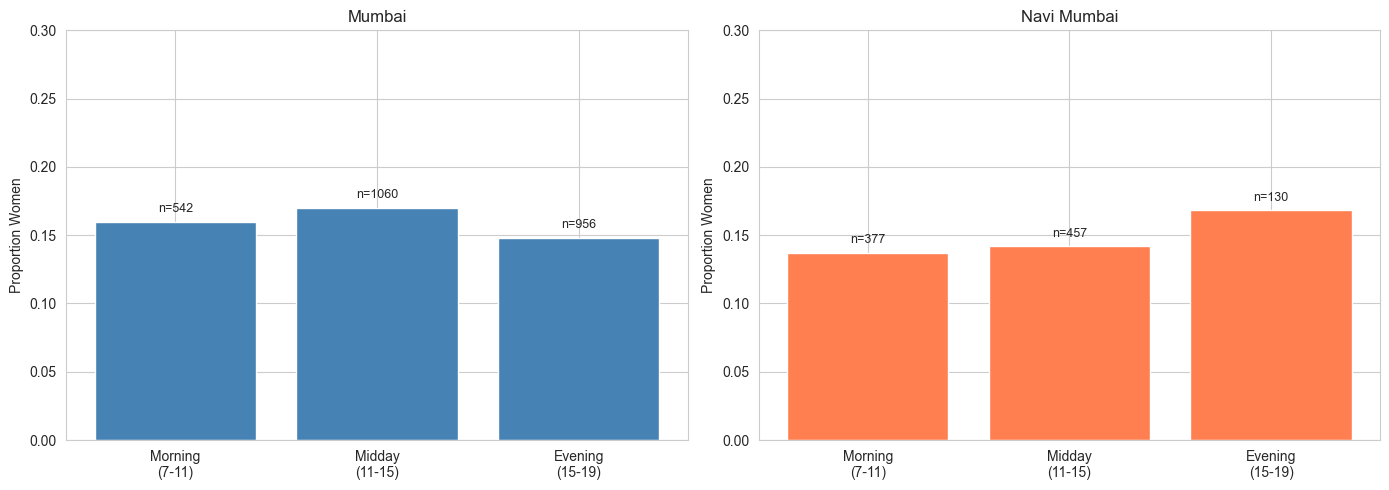

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

periods = ['Morning (7-11 IST)', 'Midday (11-15 IST)', 'Evening (15-19 IST)']
x = np.arange(len(periods))
width = 0.35

for ax, region, color in zip(axes, ['mumbai', 'navi_mumbai'], ['steelblue', 'coral']):
    region_data = df_with_people[df_with_people['region'] == region].copy()
    region_data['time_period'] = region_data['frame_hour'].apply(assign_time_period)
    
    props = []
    ns = []
    for period in periods:
        period_data = region_data[region_data['time_period'] == period]
        if len(period_data) > 0 and period_data['total_people'].sum() > 0:
            props.append(period_data['total_women'].sum() / period_data['total_people'].sum())
            ns.append(len(period_data))
        else:
            props.append(0)
            ns.append(0)
    
    bars = ax.bar(x, props, color=color)
    for bar, n in zip(bars, ns):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'n={n}',
                ha='center', va='bottom', fontsize=9)
    
    ax.set_ylabel('Proportion Women')
    ax.set_title(region.replace('_', ' ').title())
    ax.set_xticks(x)
    ax.set_xticklabels(['Morning\n(7-11)', 'Midday\n(11-15)', 'Evening\n(15-19)'])
    ax.axhline(0.5, color='green', linestyle=':', linewidth=2, label='Parity')
    ax.set_ylim(0, 0.3)

plt.tight_layout()
plt.show()

### Distribution Plots

Visualizing the distribution of proportion women across different temporal categories.

/var/folders/ks/1g8bn5m566n_w4l5hwwjv4180000gn/T/ipykernel_70427/1960847763.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)


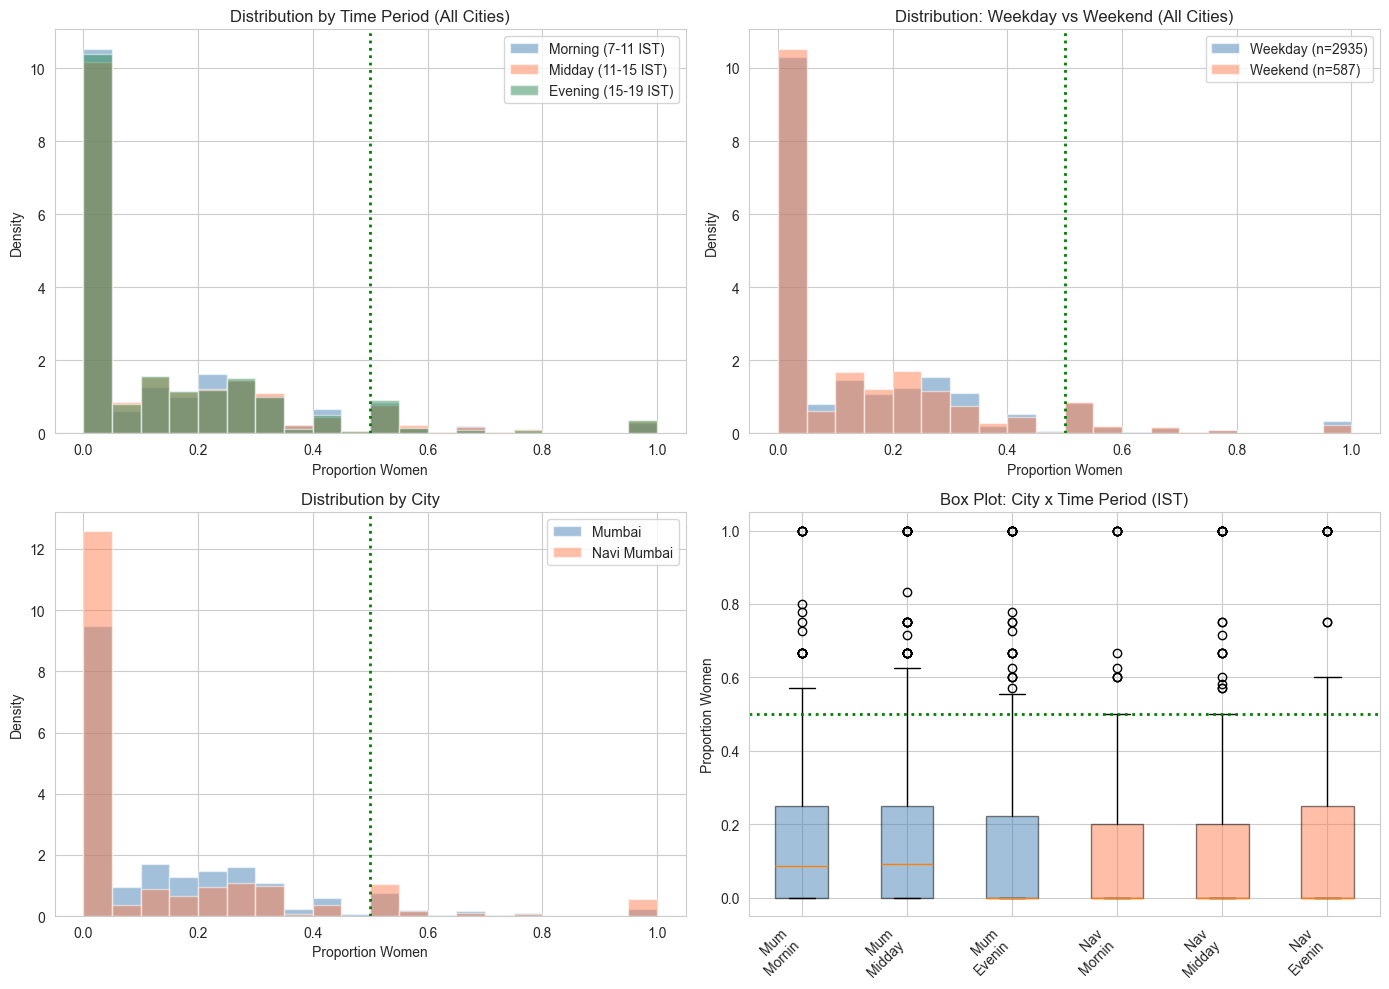

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution by time period
ax = axes[0, 0]
for period, color in [('Morning (7-11 IST)', 'steelblue'), ('Midday (11-15 IST)', 'coral'), ('Evening (15-19 IST)', 'seagreen')]:
    period_data = df_with_people[df_with_people['time_period'] == period]['prop_women'].dropna()
    if len(period_data) > 0:
        ax.hist(period_data, bins=20, alpha=0.5, label=period, color=color, density=True)
ax.set_xlabel('Proportion Women')
ax.set_ylabel('Density')
ax.set_title('Distribution by Time Period (All Cities)')
ax.legend()
ax.axvline(0.5, color='green', linestyle=':', linewidth=2)

# Distribution by weekday/weekend
ax = axes[0, 1]
weekday_pw = df_with_people[~df_with_people['is_weekend']]['prop_women'].dropna()
weekend_pw = df_with_people[df_with_people['is_weekend']]['prop_women'].dropna()
ax.hist(weekday_pw, bins=20, alpha=0.5, label=f'Weekday (n={len(weekday_pw)})', color='steelblue', density=True)
ax.hist(weekend_pw, bins=20, alpha=0.5, label=f'Weekend (n={len(weekend_pw)})', color='coral', density=True)
ax.set_xlabel('Proportion Women')
ax.set_ylabel('Density')
ax.set_title('Distribution: Weekday vs Weekend (All Cities)')
ax.legend()
ax.axvline(0.5, color='green', linestyle=':', linewidth=2)

# Distribution by city
ax = axes[1, 0]
for region, color in [('mumbai', 'steelblue'), ('navi_mumbai', 'coral')]:
    region_data = df_with_people[df_with_people['region'] == region]['prop_women'].dropna()
    ax.hist(region_data, bins=20, alpha=0.5, label=region.replace('_', ' ').title(), color=color, density=True)
ax.set_xlabel('Proportion Women')
ax.set_ylabel('Density')
ax.set_title('Distribution by City')
ax.legend()
ax.axvline(0.5, color='green', linestyle=':', linewidth=2)

# Box plots by time period and city
ax = axes[1, 1]
data_to_plot = []
labels = []
for region in ['mumbai', 'navi_mumbai']:
    region_data = df_with_people[df_with_people['region'] == region]
    for period in ['Morning (7-11 IST)', 'Midday (11-15 IST)', 'Evening (15-19 IST)']:
        period_data = region_data[region_data['time_period'] == period]['prop_women'].dropna()
        if len(period_data) >= 5:
            data_to_plot.append(period_data)
            labels.append(f"{region[:3].title()}\n{period.split('(')[0].strip()[:6]}")

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
colors_bp = ['steelblue']*3 + ['coral']*3
for patch, color in zip(bp['boxes'], colors_bp[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax.set_ylabel('Proportion Women')
ax.set_title('Box Plot: City x Time Period (IST)')
ax.axhline(0.5, color='green', linestyle=':', linewidth=2)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

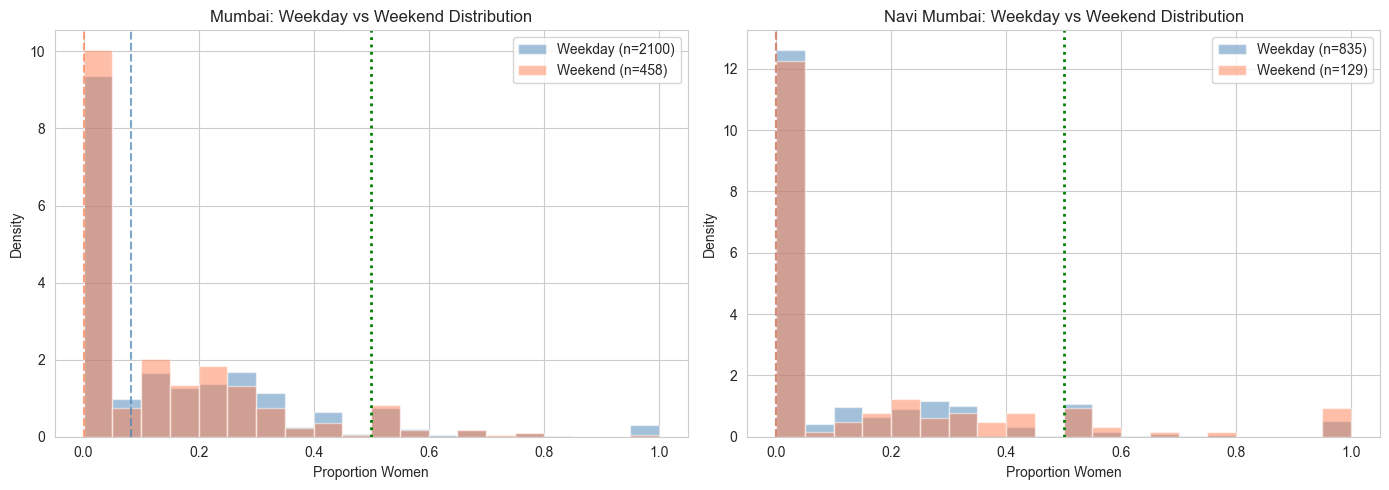

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mumbai: Weekday vs Weekend distribution
ax = axes[0]
mumbai_data = df_with_people[df_with_people['region'] == 'mumbai']
weekday_pw = mumbai_data[~mumbai_data['is_weekend']]['prop_women'].dropna()
weekend_pw = mumbai_data[mumbai_data['is_weekend']]['prop_women'].dropna()
ax.hist(weekday_pw, bins=20, alpha=0.5, label=f'Weekday (n={len(weekday_pw)})', color='steelblue', density=True)
ax.hist(weekend_pw, bins=20, alpha=0.5, label=f'Weekend (n={len(weekend_pw)})', color='coral', density=True)
ax.set_xlabel('Proportion Women')
ax.set_ylabel('Density')
ax.set_title('Mumbai: Weekday vs Weekend Distribution')
ax.legend()
ax.axvline(0.5, color='green', linestyle=':', linewidth=2)
ax.axvline(weekday_pw.median(), color='steelblue', linestyle='--', alpha=0.7)
ax.axvline(weekend_pw.median(), color='coral', linestyle='--', alpha=0.7)

# Navi Mumbai: Weekday vs Weekend distribution
ax = axes[1]
navi_data = df_with_people[df_with_people['region'] == 'navi_mumbai']
weekday_pw = navi_data[~navi_data['is_weekend']]['prop_women'].dropna()
weekend_pw = navi_data[navi_data['is_weekend']]['prop_women'].dropna()
ax.hist(weekday_pw, bins=20, alpha=0.5, label=f'Weekday (n={len(weekday_pw)})', color='steelblue', density=True)
ax.hist(weekend_pw, bins=20, alpha=0.5, label=f'Weekend (n={len(weekend_pw)})', color='coral', density=True)
ax.set_xlabel('Proportion Women')
ax.set_ylabel('Density')
ax.set_title('Navi Mumbai: Weekday vs Weekend Distribution')
ax.legend()
ax.axvline(0.5, color='green', linestyle=':', linewidth=2)
ax.axvline(weekday_pw.median(), color='steelblue', linestyle='--', alpha=0.7)
ax.axvline(weekend_pw.median(), color='coral', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

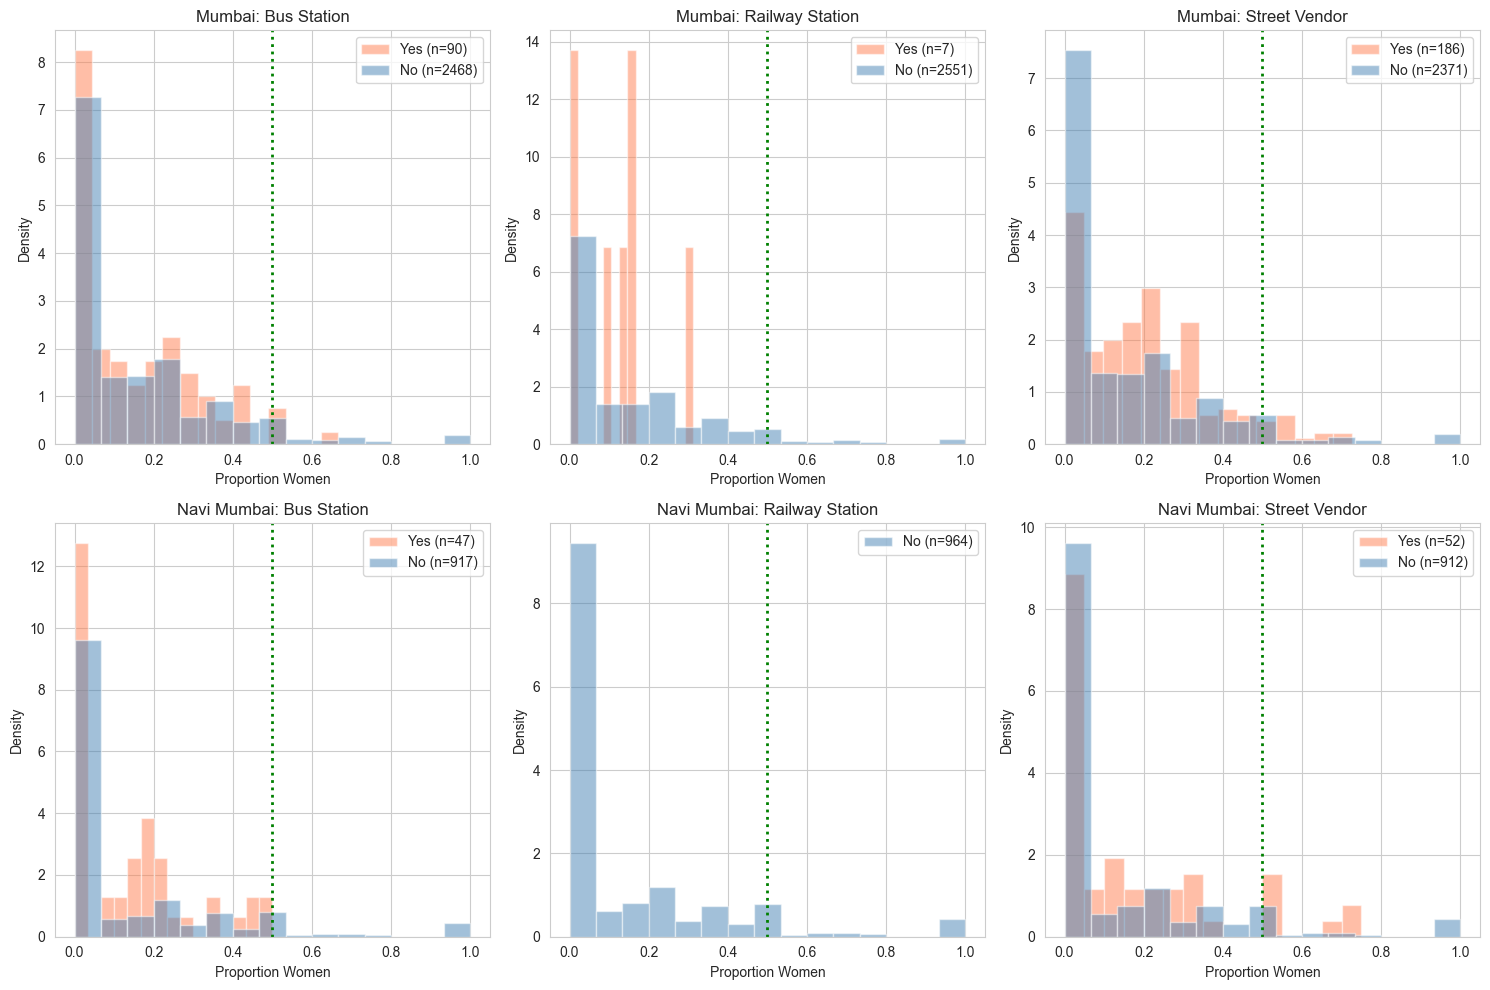

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

poi_fields = ['bus_station', 'railway_station', 'street_vendor']

for idx, (region, region_name) in enumerate([('mumbai', 'Mumbai'), ('navi_mumbai', 'Navi Mumbai')]):
    region_data = df_with_people[df_with_people['region'] == region]
    
    for col_idx, poi in enumerate(poi_fields):
        ax = axes[idx, col_idx]
        
        yes_data = region_data[region_data[poi] == 'Yes']['prop_women'].dropna()
        no_data = region_data[region_data[poi] == 'No']['prop_women'].dropna()
        
        if len(yes_data) >= 5:
            ax.hist(yes_data, bins=15, alpha=0.5, label=f'Yes (n={len(yes_data)})', color='coral', density=True)
        if len(no_data) >= 5:
            ax.hist(no_data, bins=15, alpha=0.5, label=f'No (n={len(no_data)})', color='steelblue', density=True)
        
        ax.set_xlabel('Proportion Women')
        ax.set_ylabel('Density')
        ax.set_title(f"{region_name}: {poi.replace('_', ' ').title()}")
        ax.legend()
        ax.axvline(0.5, color='green', linestyle=':', linewidth=2)

plt.tight_layout()
plt.show()

## 8. Summary & Limitations

In [30]:
print("=" * 60)
print("TEMPORAL ANALYSIS SUMMARY")
print("=" * 60)

print(f"\nData Coverage:")
print(f"  Total observations: {len(df)}")
print(f"  Hours covered (IST): ~6 AM - 8 PM")
print(f"  Days covered: All 7 days (with uneven sampling)")

print(f"\nTime of Day:")
kw_result = "significant" if p_value < 0.05 else "not significant"
print(f"  Kruskal-Wallis test: {kw_result} (p={p_value:.4f})")
print(f"  Peak hours for proportion women: {hourly_df.loc[hourly_df['prop_women_weighted'].idxmax(), 'hour']}:00 IST")

print(f"\nWeekday vs Weekend:")
print(f"  Weekday prop women: {weekday_prop:.3f}")
print(f"  Weekend prop women: {weekend_prop:.3f}")
print(f"  Mann-Whitney U: p={p_val:.4f}")

print(f"\nKey Limitations:")
print(f"  1. Thursday overrepresented (40% of data)")
print(f"  2. Wednesday underrepresented (1% of data)")
print(f"  3. Timestamps converted from UTC to IST (UTC+5:30)")

TEMPORAL ANALYSIS SUMMARY

Data Coverage:
  Total observations: 4000
  Hours covered (IST): ~6 AM - 8 PM
  Days covered: All 7 days (with uneven sampling)

Time of Day:
  Kruskal-Wallis test: significant (p=0.0000)
  Peak hours for proportion women: 7:00 IST

Weekday vs Weekend:
  Weekday prop women: 0.138
  Weekend prop women: 0.168
  Mann-Whitney U: p=0.3612

Key Limitations:
  1. Thursday overrepresented (40% of data)
  2. Wednesday underrepresented (1% of data)
  3. Timestamps converted from UTC to IST (UTC+5:30)
